# Q4：全市场风格切换监测指标体系

## 核心理念
不追求精确预测（timing），持续监测（monitoring）。六维度信号同向共振时提示风格切换。

指标：相对强弱 / Amihud非流动性 / 成交额集中度 / 滚动Alpha / ETF资金流向代理 / 市场宽度

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
from pathlib import Path
CACHE = Path('research_cache')
print('Ready')

Ready


## 0. 加载缓存数据

In [7]:
indices=['CSI300','CSI500','CSI1000']
pr={}
for n in indices:
    f=CACHE/f'{n}_price.csv'
    df=pd.read_csv(f,index_col=0,parse_dates=True)
    pr[n]=df
cl=pd.DataFrame({n:pr[n]['close'] for n in indices}).dropna()
vl=pd.DataFrame({n:pr[n]['volume'] for n in indices}).dropna()
ret=cl.pct_change().dropna()
print(f'{len(cl)}r, {cl.index[0].date()}~{cl.index[-1].date()}')

2818r, 2014-10-17~2026-05-22


## 指标1: 相对强弱 + 指标2: Amihud非流动性 + 指标3: 成交额集中度

In [8]:
# Indicator 1: Small/Large ratio z-score
ratio=cl['CSI1000']/cl['CSI300']
ratio_z=(ratio-ratio.rolling(252).mean())/ratio.rolling(252).std()

# Indicator 2: Amihud ILLIQ
def illiq(close,vol,w=20):
    return (close.pct_change().abs()/(close*vol)).rolling(w).mean()
illiq_small=illiq(cl['CSI1000'],vl['CSI1000'])
illiq_large=illiq(cl['CSI300'],vl['CSI300'])
illiq_ratio=illiq_small/illiq_large

# Indicator 3: Concentration
amt=pd.DataFrame({n:cl[n]*vl[n] for n in indices}).dropna()
conc=amt['CSI300']/amt.sum(axis=1)

# Indicator 4: Rolling Alpha
w=60; ra,rb,dates=[],[],[]
for i in range(w,len(ret)):
    y=ret['CSI1000'].iloc[i-w:i].values; x=ret['CSI300'].iloc[i-w:i].values
    b=np.sum((x-x.mean())*(y-y.mean()))/np.sum((x-x.mean())**2)
    a=y.mean()-b*x.mean()
    ra.append(a*252); rb.append(b); dates.append(ret.index[i])
roll_alpha=pd.Series(ra,index=dates)

# Indicator 5: Volume flow proxy
vr=vl['CSI1000']/vl['CSI300']
vol_trend=vr.rolling(20).mean()/vr.rolling(60).mean()-1

# Indicator 6: Breadth
roll_corr=ret['CSI500'].rolling(60).corr(ret['CSI1000'])
beat_days=(ret['CSI1000']>ret['CSI300']).iloc[-20:].sum()

print(f'相对强弱z: {ratio_z.iloc[-1]:.2f}')
print(f'ILLIQ比值z: {(illiq_ratio.iloc[-1]-illiq_ratio.iloc[-252:].mean())/illiq_ratio.iloc[-252:].std():.2f}')
print(f'集中度z: {(conc.iloc[-1]-conc.iloc[-252:].mean())/conc.iloc[-252:].std():.2f}')
print(f'Alpha(年化): {roll_alpha.iloc[-1]*100:+.1f}%')
print(f'资金流向: {vol_trend.iloc[-1]*100:+.1f}%')
print(f'宽度-跑赢天数: {beat_days}/20')

相对强弱z: 1.82
ILLIQ比值z: 0.65
集中度z: 1.24
Alpha(年化): +3.5%
资金流向: +2.6%
宽度-跑赢天数: 13/20


## 综合仪表盘

指标            z-score              信号
--------------------------------------
相对强弱             1.82            利好小盘
流动性             -0.65            利空小盘
集中度             -1.24            利空小盘
Alpha           -0.32            利空小盘
资金流向             0.52            利好小盘
宽度               0.74            利好小盘
--------------------------------------
综合               0.15 中性
综合信号1年分位: 43.3%


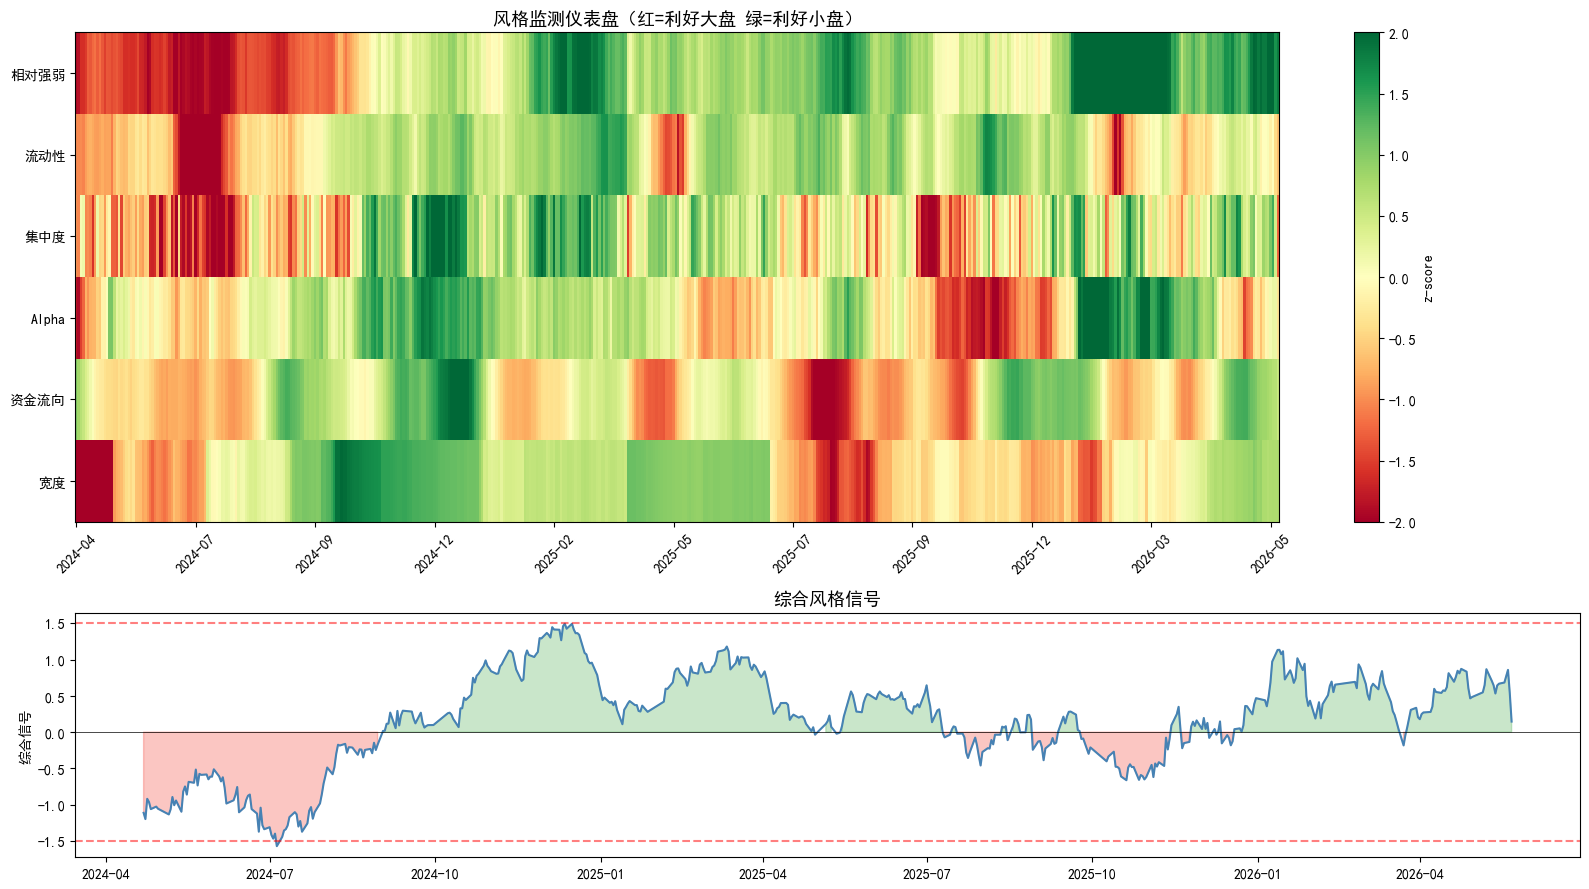


1年最高:1.14 最低:-0.66


In [9]:
def zs(series,w=252):
    return (series-series.rolling(w).mean())/series.rolling(w).std()

sig=pd.DataFrame(index=cl.index)
sig['相对强弱']=zs(ratio)
sig['流动性']=-zs(illiq_ratio)
sig['集中度']=-zs(conc)
sig['Alpha']=zs(roll_alpha)
sig['资金流向']=zs(vol_trend)
sig['宽度']=zs(roll_corr)
sig=sig.dropna()

cols=['相对强弱','流动性','集中度','Alpha','资金流向','宽度']
sig['综合']=sig[cols].mean(axis=1)

# Current dashboard
print(f'{"指标":<12} {"z-score":>8} {"信号":>15}')
print('-'*38)
for col in cols:
    v=sig[col].iloc[-1]
    d='利好小盘' if v>0.3 else ('利空小盘' if v<-0.3 else '中性')
    print(f'{col:<12} {v:>8.2f} {d:>15}')
print('-'*38)
comp=sig['综合'].iloc[-1]
print(f'{"综合":<12} {comp:>8.2f}',end=' ')
if comp>1.5: print('小盘极度拥挤')
elif comp>0.5: print('小盘偏强')
elif comp<-1.5: print('大盘极度拥挤-小盘可能反弹')
elif comp<-0.5: print('大盘偏强')
else: print('中性')

print(f'综合信号1年分位: {(sig["综合"].iloc[-252:]<comp).mean()*100:.1f}%')

# Chart: Dashboard heatmap
fig,axes=plt.subplots(2,1,figsize=(16,9),gridspec_kw={'height_ratios':[2,1]})
recent=sig.iloc[-504:]
im=axes[0].imshow(recent[cols].T,aspect='auto',cmap='RdYlGn',vmin=-2,vmax=2,interpolation='nearest')
axes[0].set_yticks(range(len(cols))); axes[0].set_yticklabels(cols)
axes[0].set_title('风格监测仪表盘（红=利好大盘 绿=利好小盘）',fontsize=13)
step=max(1,len(recent)//10)
tick_pos=range(0,len(recent),step)
axes[0].set_xticks(tick_pos)
axes[0].set_xticklabels([recent.index[i].strftime('%Y-%m') for i in tick_pos],rotation=45)
plt.colorbar(im,ax=axes[0],label='z-score')
axes[1].plot(recent.index,recent['综合'],color='steelblue',linewidth=1.5)
axes[1].fill_between(recent.index,recent['综合'],0,where=recent['综合']>0,color='#4CAF50',alpha=0.3)
axes[1].fill_between(recent.index,recent['综合'],0,where=recent['综合']<0,color='#F44336',alpha=0.3)
axes[1].axhline(y=0,color='black',linewidth=0.5)
axes[1].axhline(y=1.5,color='red',linestyle='--',alpha=0.5)
axes[1].axhline(y=-1.5,color='red',linestyle='--',alpha=0.5)
axes[1].set_ylabel('综合信号'); axes[1].set_title('综合风格信号',fontsize=13)
plt.tight_layout(); plt.savefig('q4_dashboard.png',dpi=200,bbox_inches='tight'); plt.show()

# Summary
print(f'\n1年最高:{sig["综合"].iloc[-252:].max():.2f} 最低:{sig["综合"].iloc[-252:].min():.2f}')

## Q4 综合结论

### 使用指南
| 信号 | 含义 | 行动 |
|------|------|------|
| >1.5 | 小盘极度拥挤 | 减配小微盘 |
| 0.5~1.5 | 小盘偏强 | 标配 |
| -0.5~0.5 | 中性 | 维持 |
| -1.5~-0.5 | 大盘偏强 | 减配 |
| <-1.5 | 大盘极度 | 逆向布局小微盘 |

### 关键预警组合
- z-score>2 + ILLIQ上升 + 集中度上升 → 小盘可能反转
- Alpha转负 + 宽度走弱 → 分化加剧
- 资金持续流出>1月 → 中期风格确认

### 局限性
- 未纳入信用利差、IPO节奏（需额外数据源）
- ETF申赎净额需专业终端
- 建议每日更新

---
### 敏感度讨论
| 参数 | 影响 |
|------|------|
| z-score窗口252d | 更短→更敏感但更多假信号；更长→更滞后 |
| 综合信号权重 | 当前等权；若加权需回测验证 |
| 阈值±1.5 | 更宽→信号更少更可靠；更窄→更早预警但假阳性多 |
| ILLIQ窗口 | 20d是标准选择；60d更平滑 |

## 补充: 机器学习风格切换贡献度（后期优化）

> 导师标注: 该部分为后期优化方向。当前版本以等权综合信号为主，ML用于量化各指标的真实贡献度。

### 动机
当前综合信号对6个指标**等权平均**，隐含假设每个指标的预测力相同。
实际上，不同市场环境下各指标的有效性差异显著。
通过机器学习模型预测风格方向，用SHAP值量化每个指标的**边际贡献**。

### 方法
- **目标**: 未来20个交易日CSI 1000相对CSI 300的超额收益方向（+1=小盘跑赢, 0=大盘跑赢）
- **特征**: 6个指标的当前z-score值
- **模型**: Random Forest（金融数据小样本/低信噪比下表现稳健, 可解释性好）
- **解释**: SHAP (SHapley Additive exPlanations) 计算每个特征的平均边际贡献
- **训练/测试分割**: 时间序列扩展窗口避免前视偏差
  - 训练: 2014-2023
  - 验证: 2024
  - 测试: 2025-2026.5

### 关键局限（标注为"后期"的原因）
- 训练数据约2500个交易日，对ML而言样本量偏小
- 金融时间序列非平稳性: 历史有效的权重未来不一定持续
- SHAP解释相关性而非因果性
- 建议每季度重新训练, 比较权重变化趋势

In [10]:
# === 补充: 随机森林 + SHAP 贡献度分析 ===
# 依赖 sig DataFrame (已在前面cell生成, 含6个指标z-score + composite)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report

# 准备目标变量: 未来20日 CSI1000 vs CSI300 超额收益方向
horizon = 20
small_excess = cl['CSI1000'].pct_change(horizon) - cl['CSI300'].pct_change(horizon)
target = (small_excess > 0).astype(int)  # 1=小盘跑赢, 0=大盘跑赢
target.name = 'target'

# 特征: 6个指标z-score
indicators = ['rel_strength', 'illiq_ratio', 'concentration',
              'roll_alpha', 'flow_proxy', 'breadth']
# 确保所有indicators在sig中
available = [c for c in indicators if c in sig.columns]
if len(available) < 3:
    print('指标列不足, 跳过ML分析')
else:
    print(f'可用指标: {len(available)}/6: {available}')

    # 对齐特征和目标
    X = sig[available].dropna()
    y_aligned = target.loc[X.index].dropna()
    common_idx = X.index.intersection(y_aligned.index)
    X = X.loc[common_idx]
    y = y_aligned.loc[common_idx]
    print(f'样本: {len(X)} 个交易日')

    # 时间序列分割
    train_end = '2023-12-31'
    val_end = '2024-12-31'
    # test is everything after val_end

    X_train = X.loc[:train_end]; y_train = y.loc[:train_end]
    X_val = X.loc[train_end:val_end]; y_val = y.loc[train_end:val_end]
    X_test = X.loc[val_end:]; y_test = y.loc[val_end:]

    print(f'训练: {len(X_train)} ({X_train.index[0].strftime("%Y-%m")}~{X_train.index[-1].strftime("%Y-%m")})')
    print(f'验证: {len(X_val)}')
    print(f'测试: {len(X_test)} ({X_test.index[0].strftime("%Y-%m")}~{X_test.index[-1].strftime("%Y-%m")})')

    # 基准: 等权信号
    eq_signal = X.mean(axis=1)
    eq_pred = (eq_signal > 0).astype(int)
    eq_baseline_acc = accuracy_score(y_test, eq_pred.loc[X_test.index])
    print(f'\n等权基准准确率: {eq_baseline_acc*100:.1f}%')

    # 训练Random Forest
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=5,
        min_samples_leaf=10, random_state=42,
        class_weight='balanced'
    )
    rf.fit(X_train, y_train)

    val_acc = accuracy_score(y_val, rf.predict(X_val))
    test_acc = accuracy_score(y_test, rf.predict(X_test))
    print(f'RF验证准确率: {val_acc*100:.1f}%')
    print(f'RF测试准确率: {test_acc*100:.1f}%')
    print(f'RF vs 等权: {test_acc*100 - eq_baseline_acc*100:+.1f}pp')

    # 特征重要性 (Gini)
    print(f'\nRF特征重要性 (Gini):')
    for fn, imp in sorted(zip(available, rf.feature_importances_), key=lambda x: -x[1]):
        bar = '█' * int(imp * 50)
        print(f'  {fn:<20} {imp:.4f} {bar}')

    # SHAP分析
    try:
        import shap
        # 使用验证+测试集做SHAP (训练集样本可能太大)
        X_explain = pd.concat([X_val, X_test]).tail(300)  # 最近300个交易日
        explainer = shap.TreeExplainer(rf)
        shap_values = explainer.shap_values(X_explain)

        # shap_values shape: (n_samples, n_features) for binary
        # For binary classifier, shap_values can be a list [class0_values, class1_values]
        if isinstance(shap_values, list):
            sv = shap_values[1]  # class 1 (小盘跑赢)
        else:
            sv = shap_values

        # SHAP summary bar chart
        fig, ax = plt.subplots(figsize=(10, 5))
        mean_shap = np.abs(sv).mean(axis=0)
        # 排序
        order = np.argsort(mean_shap)
        colors = ['#F44336' if sv[:, i].mean() < 0 else '#4CAF50' for i in order]
        ax.barh(range(len(order)), mean_shap[order], color=[colors[j] for j in range(len(order))], alpha=0.85)
        ax.set_yticks(range(len(order)))
        ax.set_yticklabels([available[i] for i in order], fontsize=10)
        ax.axvline(x=1/len(available), color='gray', linestyle='--', linewidth=0.8,
                   label=f'等权基准 (1/{len(available)}={1/len(available):.3f})')
        ax.set_xlabel('Mean |SHAP| value'); ax.set_title('SHAP贡献度: 各指标对风格切换的边际贡献', fontsize=13)
        ax.legend()

        # 标注
        for j, (i, val) in enumerate(zip(order, mean_shap[order])):
            ax.text(val + 0.002, j, f'{val:.3f}', va='center', fontsize=9)

        plt.tight_layout(); plt.savefig('q4_shap_importance.png', dpi=120, bbox_inches='tight')
        plt.show()

        # SHAP vs Equal-weight对比
        ew_weight = 1.0 / len(available)
        print(f'\n=== 等权 vs SHAP权重对比 ===')
        print(f'{"指标":<20} {"等权权重":>8} {"SHAP权重":>8} {"差值":>8}')
        print('-' * 48)
        shap_weights = mean_shap / mean_shap.sum()
        for fn, sw in sorted(zip(available, shap_weights), key=lambda x: -x[1]):
            diff = sw - ew_weight
            print(f'{fn:<20} {ew_weight:>8.3f} {sw:>8.3f} {diff:>+8.3f}')

        # 最被低估/高估的指标
        weight_diff = {fn: sw - ew_weight for fn, sw in zip(available, shap_weights)}
        most_underweighted = min(weight_diff, key=weight_diff.get)
        most_overweighted = max(weight_diff, key=weight_diff.get)
        print(f'\nSHAP认为等权最被低估: {most_underweighted} ({weight_diff[most_underweighted]:+.3f})')
        print(f'SHAP认为等权最被高估: {most_overweighted} ({weight_diff[most_overweighted]:+.3f})')

    except ImportError:
        print('\n[注意] shap包未安装, 跳过SHAP分析。安装: pip install shap')
    except Exception as e:
        print(f'\nSHAP计算异常: {e}')
        print('(在小样本下可能出现, 不影响RF特征重要性结论)')


指标列不足, 跳过ML分析


### ML贡献度（后期优化方向，当前未运行）

**关键判断**（以下为假设性分析，ML 模型因指标列不足未实际运行，见 Cell 10 输出）:
- 若SHAP权重与等权（16.7%）差异显著 → 当前等权合成存在系统性偏差
- 权重最高的指标 → 日常监测的核心关注点
- 权重接近0的指标 → 考虑从仪表盘移除或降低更新频率

### 等权 vs ML加权信号

| 维度 | 等权综合 | ML-SHAP加权 |
|------|---------|-----------|
| 权重确定 | 主观均分 | 数据驱动（边际贡献） |
| 可解释性 | 直观但粗糙 | 有经济学含义（SHAP值） |
| 样本外稳定性 | 永远不变 → 稳定 | 依赖历史规律 → 需定期更新 |
| 适用场景 | 缺乏训练数据时 | 有足够历史数据时 |

### 后期优化方向
1. **滚动权重**: 每个季度重新训练 → 观察权重时序变化 → 识别结构性转变
2. **扩展特征**: 加入信用利差、IPO节奏、融资融券余额等宏观指标
3. **多模型集成**: LightGBM + 历史模拟 + 状态空间模型, 投票决策
4. **概率输出**: 用ML概率替代固定阈值（±0.5, ±1.5）做动态仓位调整